# Blood Donation Data Analysis and Prediction Using Machine Learning

## Introduction

Blood donation is an essential part of healthcare systems and helps save lives during surgeries, emergencies, and medical treatments. 
Maintaining sufficient blood supply is a major challenge because many donors do not return for repeat donations.

This project focuses on analyzing blood donor behavior and predicting whether a donor will donate blood again using machine learning techniques.
By identifying important factors influencing repeat donation, blood banks can improve donor retention strategies and manage blood supply more effectively.

## Machine Learning Pipeline

The following pipeline was followed in this project:

- Problem Definition
- Data 
- Evaluvation 
- Features 
- Modelling 
- Experimentation

# Problem statement

Can we efficiently predict whether a blood donor is likely to donate blood again based on their previous donation history?

## Data

The dataset was provided by Datamites as part of the capstone project. 
The data contains historical blood donation records collected by a mobile blood donation vehicle in Taiwan.
The dataset includes donor-related attributes such as recency, frequency, total blood volume donated, and donor history.
# Data set Link:
                https://d3ilbtxij3aepc.cloudfront.net/projects/CDS-Capstone-Projects/PRCP-1011-BloodDonaPred.zip

## Evaluation
The objective is to develop a machine learning model capable of accurately predicting whether a donor will donate blood in March 2007.
Model performance will be evaluated using Accuracy, Precision, Recall, F1-Score, ROC-AUC Score, and Confusion Matrix.
The model with the best overall performance will be selected for deployment

### Features
Various features will be identified and detailed 

# Data dictionary
1. **Unnamed**: No name is given but it represents a unique 'int' value corresponding to the donors ID.
2. **Months since Last Donation**: this is the number of months since this donor's most recent donation.
3. **Number of Donations**: this is the total number of donations that the donor has made.
4. **Total Volume Donated**: this is the total amount of blood that the donor has donated in cubuc centimeters.
5. **Months since First Donation**: this is the number of months since the donor's first donation
6. **Made Donation in March 2007**: Target variable indicating whether the donor donated blood in March 2007 (1 = Donated, 0 = Not Donated).

## Preparing the tools 
we're going to use several libraries to aid our model, some of them are listed below:









In [1]:
# Import all the tools we need

# Regular EDA(Exploratory data analysis) and plotting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# we want our plots to appear inside the notebook
%matplotlib inline 

# Models from Scikit-Learn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Model Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score,f1_score
from sklearn.metrics import roc_auc_score


In [2]:
df = pd.read_csv("blood_donation.csv")   
df

,Unnamed: 0,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
0,619,2,50,12500,98,1
1,664,0,13,3250,28,1
2,441,1,16,4000,35,1
3,160,2,20,5000,45,1
4,358,1,24,6000,77,0
...,...,...,...,...,...,...
571,698,23,1,250,23,0
572,433,16,3,750,86,0
573,360,21,2,500,52,0
574,541,39,1,250,39,0


### Data Exploration
The goal here is to find more about data and become a subject matter export on the dataset you're working with.

- What question(s) are you going to solve?
- What kind of data do we have ans how do we treat different types?
- What's missing from the data and how do you deal with it? 
- Where are the outliers and why should you care about them?   
- How can you add, change or remove features to get more out of you data?
    

In [3]:
#checking first five rows
df.head()

,Unnamed: 0,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
0,619,2,50,12500,98,1
1,664,0,13,3250,28,1
2,441,1,16,4000,35,1
3,160,2,20,5000,45,1
4,358,1,24,6000,77,0


In [4]:
#checking last five rows
df.tail()

,Unnamed: 0,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
571,698,23,1,250,23,0
572,433,16,3,750,86,0
573,360,21,2,500,52,0
574,541,39,1,250,39,0
575,74,72,1,250,72,0


In [5]:
df['Made Donation in March 2007'].value_counts()

Made Donation in March 2007
0    438
1    138
Name: count, dtype: int64

In [6]:
#checking the info
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Unnamed: 0                   576 non-null    int64
 1   Months since Last Donation   576 non-null    int64
 2   Number of Donations          576 non-null    int64
 3   Total Volume Donated (c.c.)  576 non-null    int64
 4   Months since First Donation  576 non-null    int64
 5   Made Donation in March 2007  576 non-null    int64
dtypes: int64(6)
memory usage: 27.1 KB


In [7]:
#Checking the describe functions
df.describe()

,Unnamed: 0,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
count,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000
mean,374.034722,9.439236,5.427083,1356.770833,34.050347,0.239583
std,216.947773,8.175454,5.740010,1435.002556,24.227672,0.427200
min,0.000000,0.000000,1.000000,250.000000,2.000000,0.000000
25%,183.750000,2.000000,2.000000,500.000000,16.000000,0.000000
50%,375.500000,7.000000,4.000000,1000.000000,28.000000,0.000000
75%,562.500000,14.000000,7.000000,1750.000000,49.250000,0.000000
max,747.000000,74.000000,50.000000,12500.000000,98.000000,1.000000


In [8]:
# Are there any missing values?
df.isna().sum()

Unnamed: 0                     0
Months since Last Donation     0
Number of Donations            0
Total Volume Donated (c.c.)    0
Months since First Donation    0
Made Donation in March 2007    0
dtype: int64

# Renaming the data and dropping unwanted columns

In [9]:
df.rename(columns={'Months since Last Donation': 'msld',
                   'Number of Donations':'nod' ,
                   'Total Volume Donated (c.c.)':'tvd',
                   'Months since First Donation':'msfd',
                   'Made Donation in March 2007':'target'}, inplace = True )
df.drop('Unnamed: 0', axis=1, inplace=True) 

In [10]:
df.head()

,msld,nod,tvd,msfd,target
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0


# Exploratory Data Analysis
We will Perform Two Types of Analysis.
- Univariate 
- Bivariate

# Univariate Analysis
We will do Data Visualization to check the data

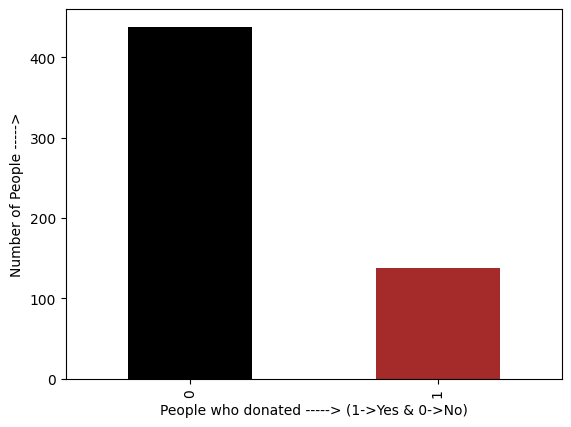

In [11]:
#analysing the number of people who donated
df.target.value_counts().plot( kind='bar', color=['black','brown']);
plt.xlabel('People who donated -----> (1->Yes & 0->No)');
plt.ylabel('Number of People ----->');

<Figure size 1000x500 with 0 Axes>

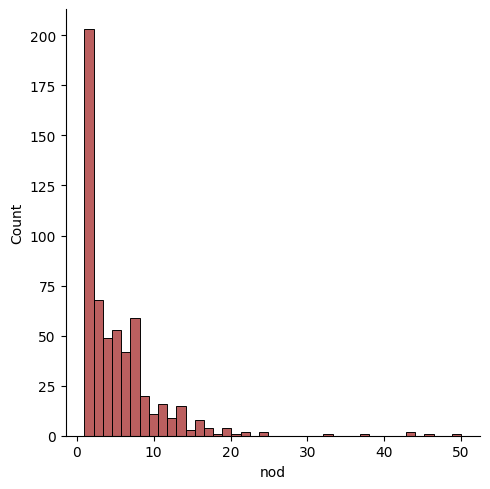

In [12]:
plt.figure(figsize = (10,5))
sns.displot(df.nod.dropna(axis=0),color='brown')
plt.show()

<Figure size 1000x500 with 0 Axes>

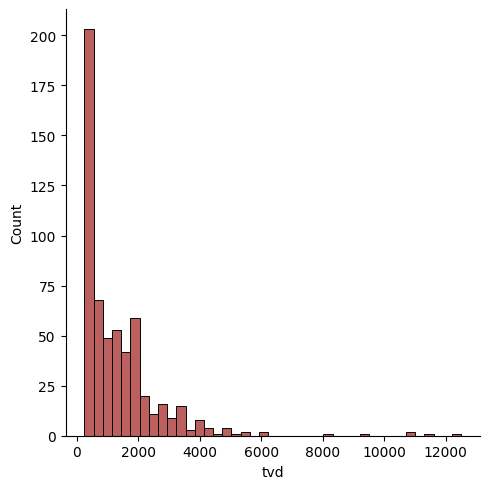

In [13]:
plt.figure(figsize = (10,5))
sns.displot(df.tvd.dropna(axis=0),color='brown')
plt.show()

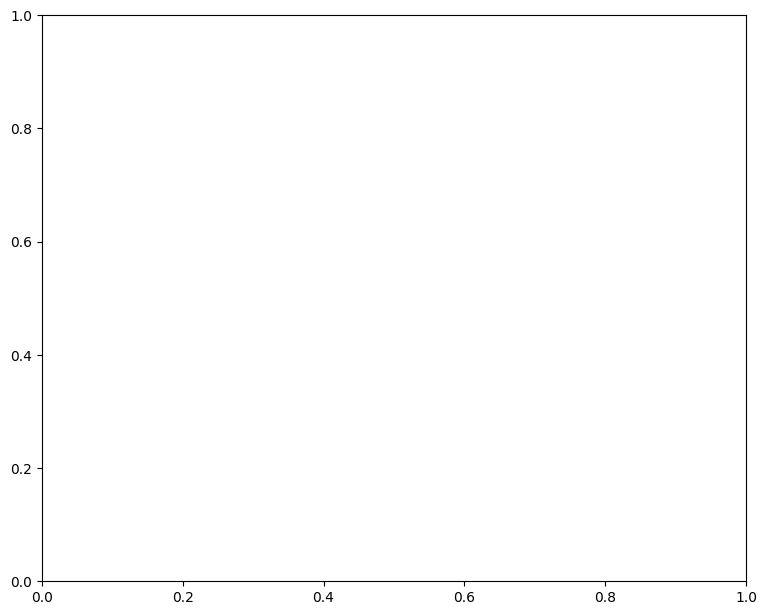

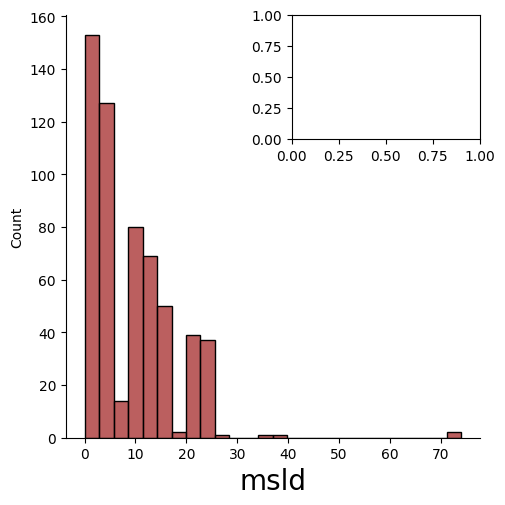

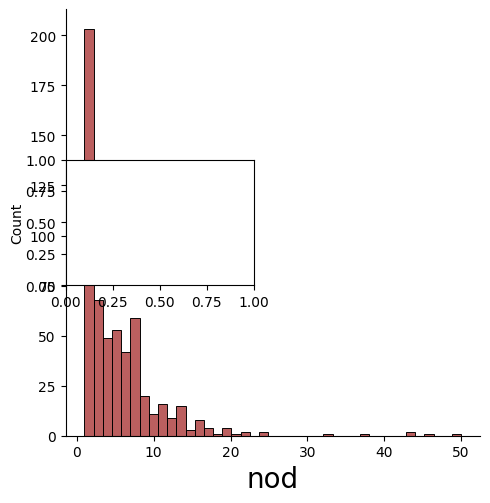

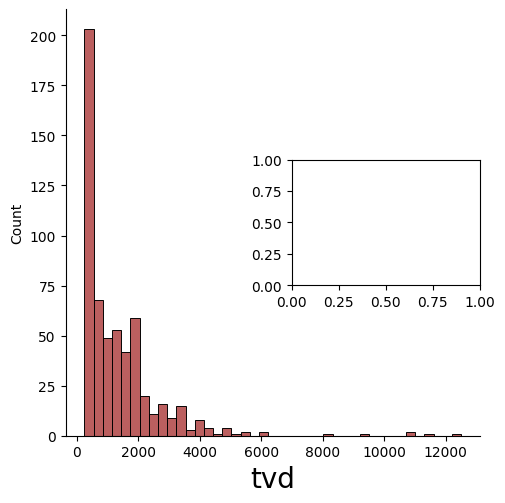

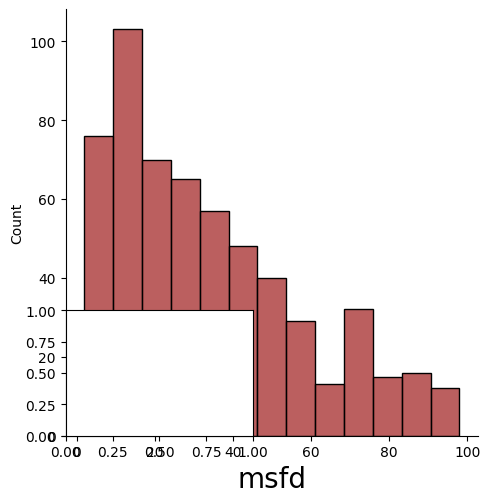

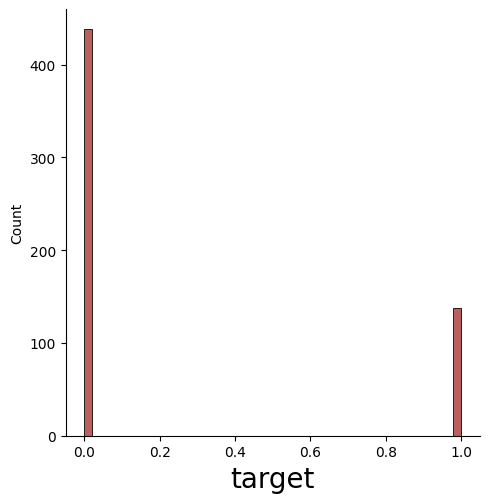

In [14]:
# let's see how data is distributed for every column
plt.figure(figsize=(20,25), facecolor='white')
plotnumber = 1


for column in df:
    if plotnumber<=5 :     # as there are 9 columns in the data
        ax = plt.subplot(3,2,plotnumber)
        sns.displot(df[column], color = 'brown')
        plt.xlabel(column,fontsize=20)
        
    plotnumber+=1
plt.show()

We can see from the graphs that there is some skewness in the data.

# Bivariate Analysis
We will check the heatmap for the types of correlation.
There are two types of correlation :
- Positive Correlation.
- Negative Correlation.

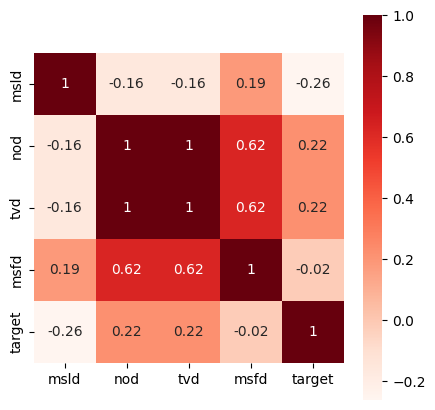

In [15]:
plt.figure(figsize = (5,5))
sns.heatmap(df.corr(), cmap= 'Reds', annot = True , cbar=True , square= True  ) 
plt.show()

## The positve correlation:
- Month since last donated:   Month since first donated
- Number of Donations:   Month since first donated ,   Made donation in March 2007
- Total Volume Donated:   Month since first donated ,   Made donation in March 2007
- Month since first donated:    Number of Donations ,   Total Volume Donated

## The Negative correlation:
- Month since last donated:   Number of Donations,   Total Volume Donated ,   Made donation in March 2007
- Number of Donations:   Month since last donated
- Total Volume Donated:     Month since last donated
- Month since first donated: Made donation in March 2007

### Analysing Months since last donation with respect to Months since first donation.
We will compare the two data to check if it is a deciding variable in the prediction.

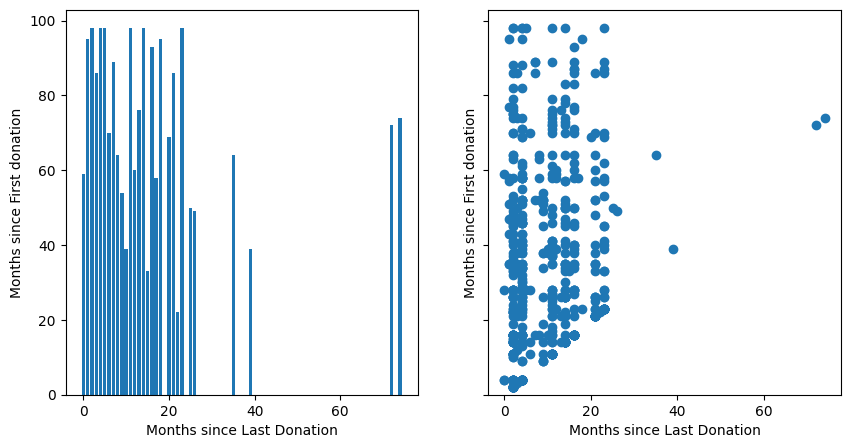

In [16]:
fig, axs = plt.subplots(1,2,figsize=(10,5),sharey = True)

#first plot
axs[0].bar(df.msld, df.msfd)

axs[0].set_xlabel('Months since Last Donation')
axs[0].set_ylabel('Months since First donation')

#second plot
axs[1].scatter(df.msld, df.msfd)

axs[1].set_xlabel('Months since Last Donation')
axs[1].set_ylabel('Months since First donation')
plt.show()

Month since Last Donated and Volume Donated


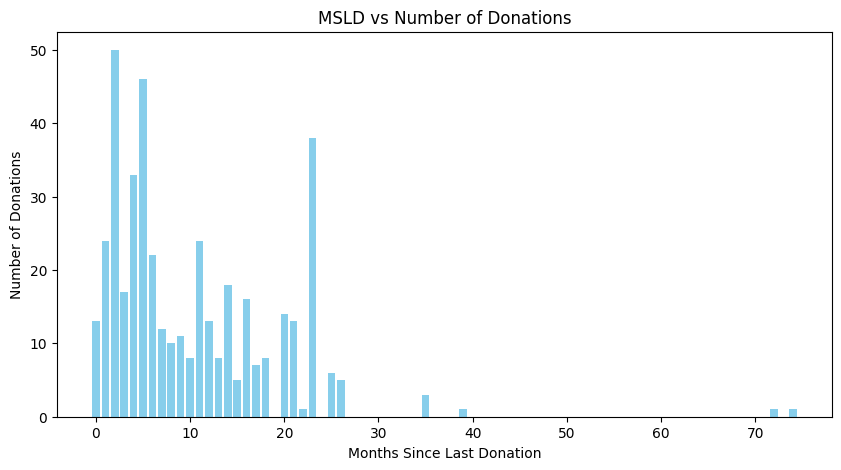

In [17]:
plt.figure(figsize=(10,5))

plt.bar(df["msld"], df["nod"], color="skyblue")

plt.xlabel("Months Since Last Donation")
plt.ylabel("Number of Donations")
plt.title("MSLD vs Number of Donations")
plt.show()

### Month since Last Donated and Donation Made in March

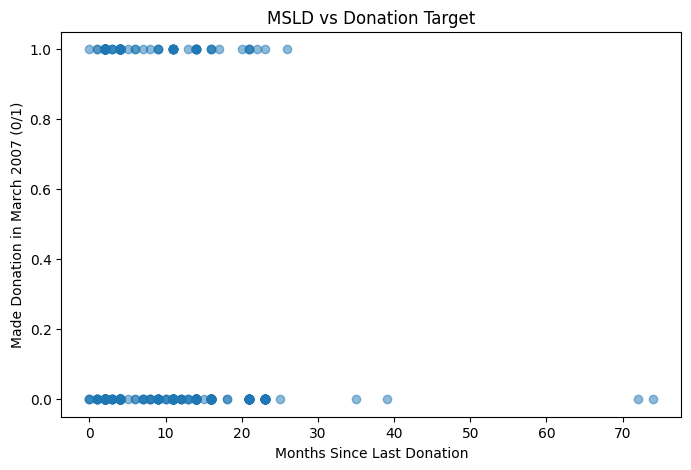

In [18]:
plt.figure(figsize=(8,5))

plt.scatter(df["msld"], df["target"], alpha=0.5)

plt.xlabel("Months Since Last Donation")
plt.ylabel("Made Donation in March 2007 (0/1)")
plt.title("MSLD vs Donation Target")

plt.show()

Checking if there are duplicate rows


In [19]:
df.duplicated().sum()

np.int64(153)

In [20]:
df = df.drop_duplicates(keep = False)

In [21]:
df.duplicated().sum()

np.int64(0)

## Outlier Detection Using Boxplots (Seaborn Visualization)

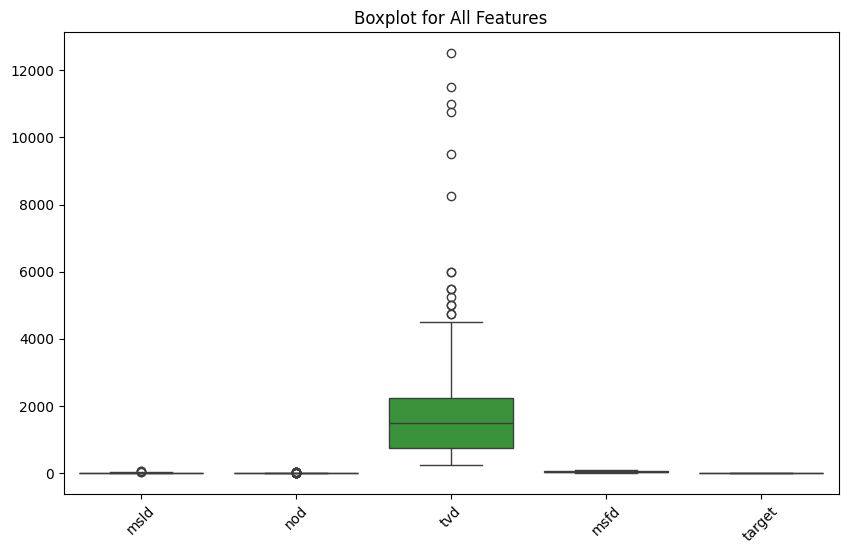

In [22]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Boxplot for All Features")
plt.show()

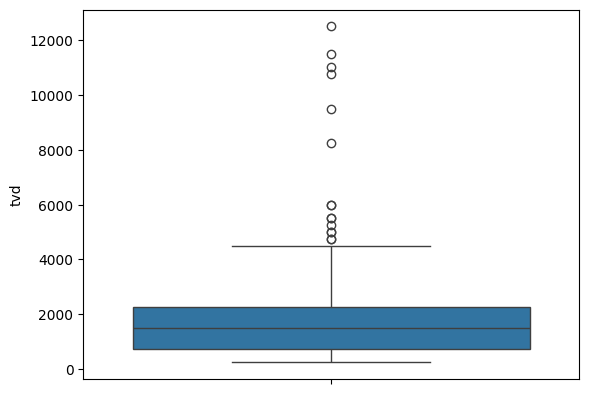

In [23]:
sns.boxplot(df.tvd)
plt.show()

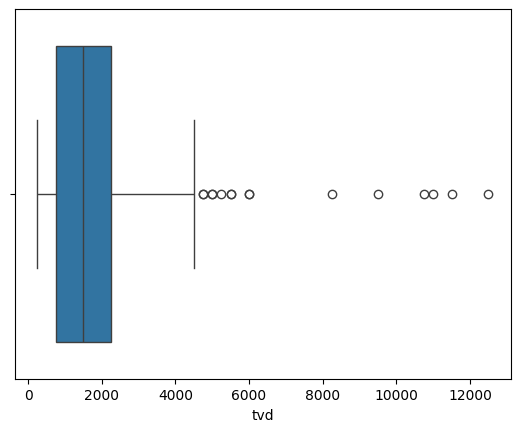

In [24]:
sns.boxplot(x=df['tvd'])
plt.show()

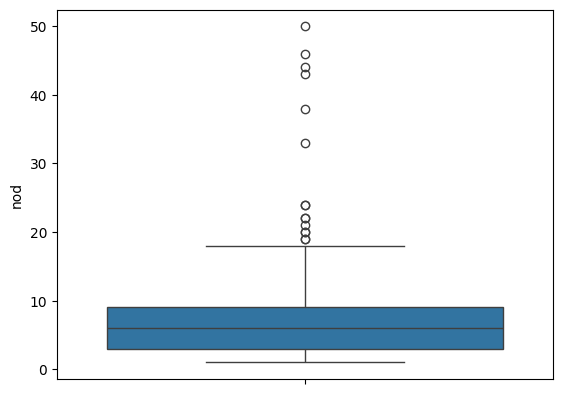

In [25]:
sns.boxplot(df.nod)
plt.show()

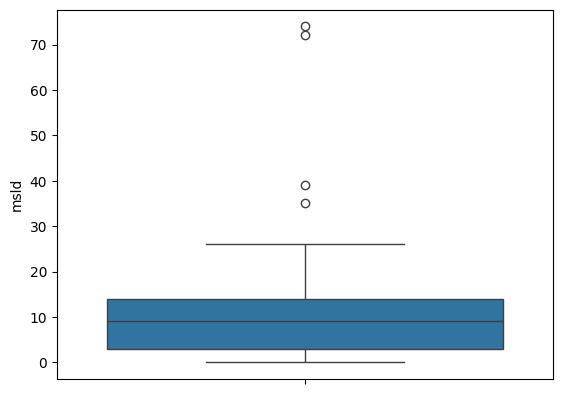

In [26]:

sns.boxplot(df.msld)
plt.show()

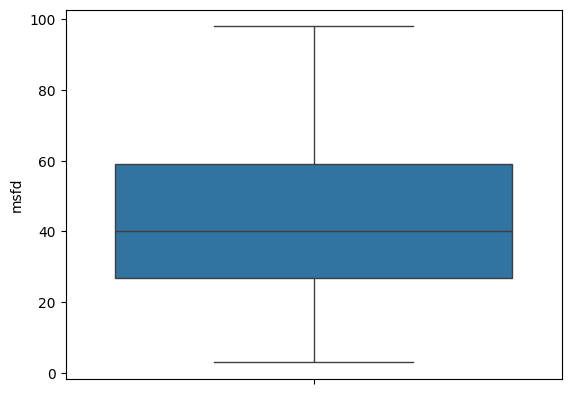

In [27]:
sns.boxplot(df.msfd)
plt.show()

There are many outliers in the Total volume donated portion. We must remove them using IQR (Inter Quartile Range),
This is calculated by using upper bounds and lower bounds whose formulas are defined as :
- Lower bound: (Q1-1.5*IQR)
- Upper bound: (Q3+1.5*IQR)
- IQR = Q3 - Q1, where Q1 and Q3 represent the 25th and 75th Percentile respectfully

# For Total volume donated Outliers

In [28]:
# Interquartile range (IQR) 
from scipy import stats
IQR = stats.iqr(df.tvd, interpolation = 'midpoint') 
## min and max limit calculation
# First quartile (Q1) 
Q1 = df.tvd.quantile(0.25)
# Third quartile (Q3) 
Q3 =df.tvd.quantile(0.75)
##getting the limits
min_limit=Q1 - 1.5*IQR

max_limit=Q3 +1.5*IQR

In [29]:
min_limit

np.float64(-1500.0)

In [30]:
df.loc[df['tvd'] > max_limit]

,msld,nod,tvd,msfd,target
0,2,50,12500,98,1
3,2,20,5000,45,1
4,1,24,6000,77,0
8,5,46,11500,98,1
37,4,20,5000,69,1
47,4,19,4750,69,1
92,11,24,6000,64,0
188,11,22,5500,98,0
263,23,38,9500,98,0
386,2,43,10750,86,1


In [31]:
df.loc[df['tvd'] > max_limit, 'tvd']=np.median(df.tvd) #median(df.tvd)

C:\Users\yarra\AppData\Local\Temp\ipykernel_24580\1041874589.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[df['tvd'] > max_limit, 'tvd']=np.median(df.tvd) #median(df.tvd)


Outliers in the tvd variable were detected using the IQR method.
The lower and upper bounds were calculated using Q1, Q3, and IQR values. 
    

C:\Users\yarra\AppData\Local\Temp\ipykernel_24580\542239162.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[df['nod'] > max_limit, 'nod']= np.median(df.nod)


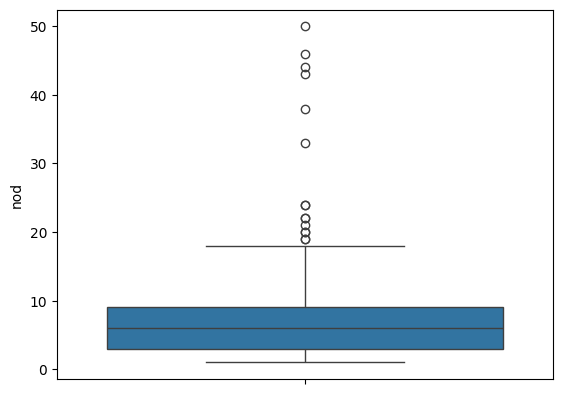

In [32]:
#FIRST TIME
df.loc[df['nod'] > max_limit, 'nod']= np.median(df.nod)
sns.boxplot(df.nod)
plt.show()

C:\Users\yarra\AppData\Local\Temp\ipykernel_24580\2400226132.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[df['nod'] > max_limit, 'nod']= np.median(df.nod)


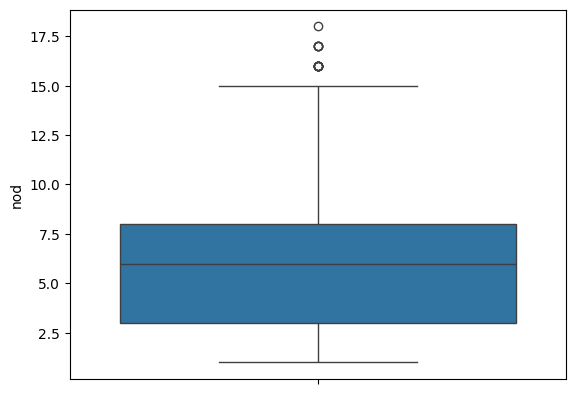

In [33]:
#SECOND TIME
IQR = stats.iqr(df.nod, interpolation = 'midpoint') 
Q1 = df.nod.quantile(0.25) 
Q3 =df.nod.quantile(0.75)
min_limit=Q1 - 1.5*IQR
max_limit=Q3 +1.5*IQR
df.loc[df['nod'] > max_limit, 'nod']= np.median(df.nod)
sns.boxplot(df.nod)
plt.show()

For the rest of the variables, a for loop was implemented to detect and handle outliers automatically using the IQR technique.

C:\Users\yarra\AppData\Local\Temp\ipykernel_24580\274866006.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[df[col_name] > max_limit, col_name] = np.median(df[col_name])
C:\Users\yarra\AppData\Local\Temp\ipykernel_24580\274866006.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[df[col_name] > max_limit, col_name] = np.median(df[col_name])


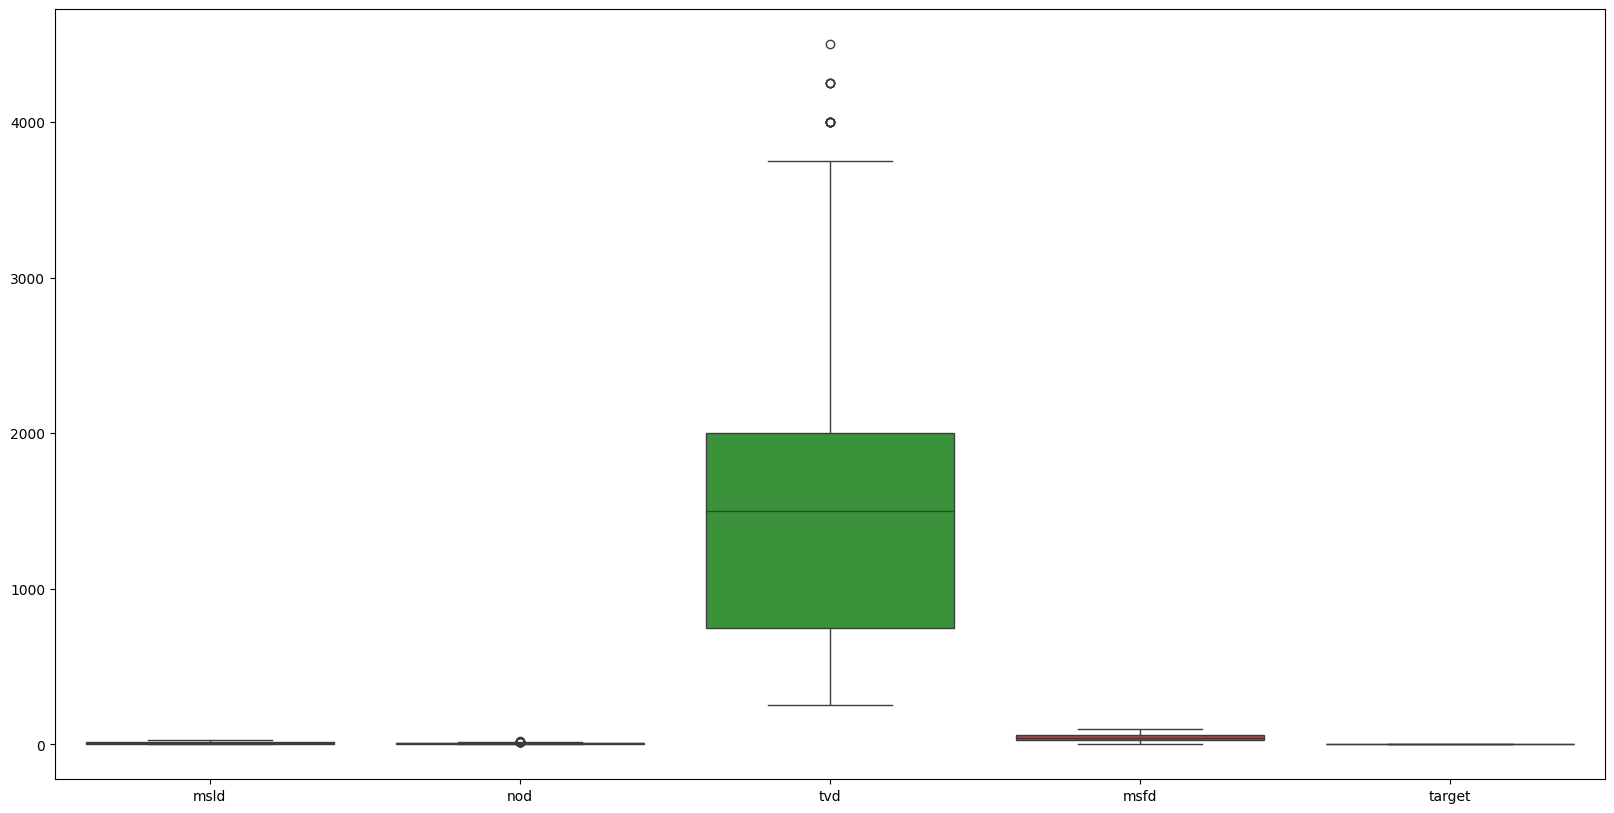

In [34]:
col = ['msld', 'msfd']

for col_name in col:
    IQR = stats.iqr(df[col_name], interpolation='midpoint')
    Q1 = df[col_name].quantile(0.25)
    Q3 = df[col_name].quantile(0.75)

    min_limit = Q1 - 1.5 * IQR
    max_limit = Q3 + 1.5 * IQR

    df.loc[df[col_name] > max_limit, col_name] = np.median(df[col_name])

fig, axs = plt.subplots(figsize=(20,10))
sns.boxplot(data=df, ax=axs)
plt.show()

Since outliers were still observed in the msld variable, the IQR method was applied once again to handle the remaining extreme values.

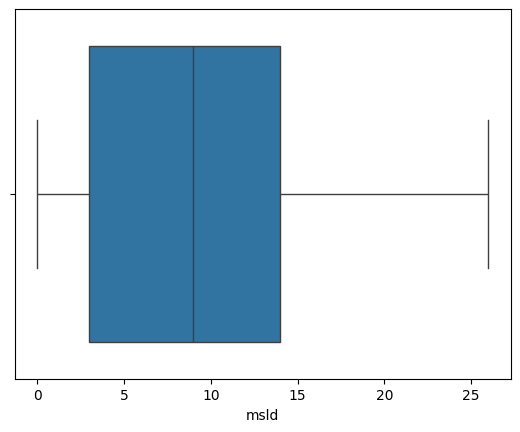

In [35]:
sns.boxplot(x=df.msld)
plt.show()

C:\Users\yarra\AppData\Local\Temp\ipykernel_24580\1876894098.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[df['msld'] > max_limit, 'msld'] = np.median(df.msld)


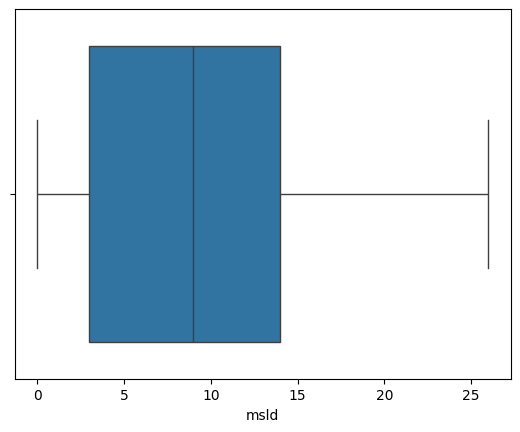

In [36]:
IQR = stats.iqr(df.msld, interpolation='midpoint')

Q1 = df.msld.quantile(0.25)
Q3 = df.msld.quantile(0.75)

min_limit = Q1 - 1.5 * IQR
max_limit = Q3 + 1.5 * IQR

df.loc[df['msld'] > max_limit, 'msld'] = np.median(df.msld)

sns.boxplot(x=df.msld)
plt.show()

All outliers have been handled successfully. 
We can now proceed to the modelling phase, where predictive models will be developed and evaluated.

# Modelling


Setting Up Training and Testing Data

Training data was used to build the model, while testing data was prepared to evaluate its performance on unseen data.

In [37]:
X = df.drop('target', axis=1)
y = df['target']

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [39]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.3,
    random_state=42
)

The data was divided into 70% training data and 30% testing data for model training and evaluation.

## Let us compare the Different  Machine Learning Models

Different machine learning models were trained and compared to determine which model provides the best prediction performance.

In [40]:
# Put Models in a Dictionary
models = {
    "Logistic Regression":LogisticRegression(),
    "KNN":KNeighborsClassifier(),
    "Random Forest":RandomForestClassifier()
}

# Create a function to fit and score models
def fit_and_score(models, x_train, x_test, y_train, y_test):
    # set random seeds
    np.random.seed(42)
    # Make a dictionary to keep model scores
    model_scores = {}
    # Loop through models
    for name, model in models.items():
        # Fit the model to the data
        model.fit(x_train, y_train)
        # Evaluate the model and append its score to model_scores
        model_scores[name] = model.score(x_test, y_test)
    return model_scores

In [41]:
model_scores = fit_and_score(models=models,
                             x_train=x_train,
                             x_test=x_test,
                             y_train = y_train,
                             y_test = y_test)

In [42]:
model_scores

{'Logistic Regression': 0.7522123893805309,
 'KNN': 0.7699115044247787,
 'Random Forest': 0.672566371681416}

Based on the model comparison, the KNN classifier demonstrated the best predictive performance on the test dataset and was chosen as the final model for this problem.

<Figure size 1000x500 with 0 Axes>

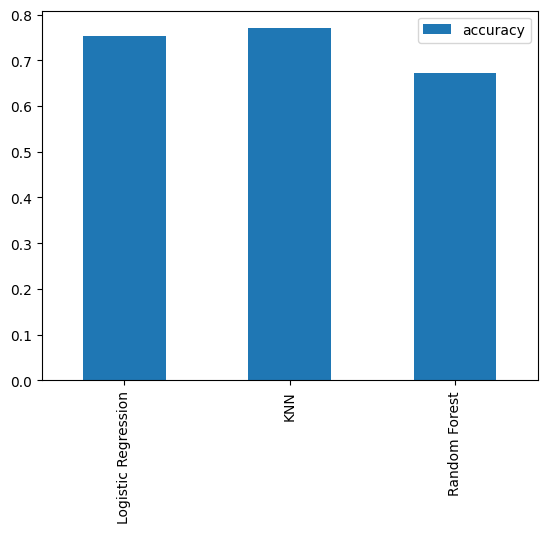

In [43]:
plt.figure(figsize=(10,5))
cmp = pd.DataFrame(model_scores, index=["accuracy"])
cmp.T.plot.bar()
plt.show()

In [44]:
# Defining the feature and target variables
X = df.drop(columns=['target'])
y = df['target']

In [45]:
X

,msld,nod,tvd,msfd
0,2,6,1500,98
1,0,13,3250,28
2,1,16,4000,35
3,2,6,1500,45
4,1,6,1500,77
...,...,...,...,...
566,23,1,250,23
572,16,3,750,86
573,21,2,500,52
574,9,1,250,39


In [46]:
y

0      1
1      1
2      1
3      1
4      0
      ..
566    1
572    0
573    0
574    0
575    0
Name: target, Length: 376, dtype: int64

In [47]:
scaler = StandardScaler()

StandardScaler was applied to normalize the feature values and bring them to a common scale.

In [48]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [49]:
print(X_scaled)

[[-1.05947616 -0.06477541 -0.06477541  2.36176964]
 [-1.3539056   1.80872877  1.80872877 -0.72486708]
 [-1.20669088  2.61165913  2.61165913 -0.41620341]
 ...
 [ 1.73760354 -1.13534923 -1.13534923  0.33340837]
 [-0.02897311 -1.40299268 -1.40299268 -0.23982417]
 [-0.02897311 -1.40299268 -1.40299268  1.21530457]]


In [50]:
log_reg = LogisticRegression()
log_reg.fit(x_train, y_train)

y_pred = log_reg.predict(x_test)
y_pred

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0])

Logistic Regression was applied to the training data, and predictions were generated for the test data.

In [51]:
Precision = precision_score(y_test,y_pred)
Precision

0.3333333333333333

In [52]:
Recall = recall_score(y_test,y_pred)
Recall

0.07692307692307693

In [53]:
F1_score = f1_score(y_test,y_pred)
F1_score

0.125

In [54]:
auc = roc_auc_score(y_test,y_pred)
auc

0.515473032714412

In [55]:
report= classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.78      0.95      0.86        87
           1       0.33      0.08      0.12        26

    accuracy                           0.75       113
   macro avg       0.55      0.52      0.49       113
weighted avg       0.67      0.75      0.69       113



The Logistic Regression model achieved 75.22% accuracy. It performed well in predicting non-repeat donors but showed low precision (33%), recall (8%), and F1-score (12%) for repeat blood donors, indicating limited effectiveness in identifying positive cases.

In [56]:
log_reg_grid = {
    "C": np.logspace(-4, 4, 20),
    "solver": ["liblinear"]
}

In [57]:
np.random.seed(20)
rs_log_reg = RandomizedSearchCV(LogisticRegression(),  param_distributions=log_reg_grid,  cv=5 , n_iter=20, verbose=True)
rs_log_reg.fit(x_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': array([1.0000...00000000e+04]), 'solver': ['liblinear']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fol

In [58]:
rs_log_reg.best_params_

{'solver': 'liblinear', 'C': np.float64(0.012742749857031334)}

In [59]:
rs_log_reg.score(x_test, y_test)

0.7522123893805309

## Hypertune our Model (by GridsearchSearchCV )


In [60]:
log_reg_grid = {
    "C": np.logspace(-4, 4, 30),
    "solver": ["liblinear"]
}

gs_log_reg = GridSearchCV(
    LogisticRegression(),
    param_grid=log_reg_grid,
    cv=5,
    verbose=True
)

gs_log_reg.fit(x_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': array([1.0000...00000000e+04]), 'solver': ['liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the

In [61]:
gs_log_reg.best_params_

{'C': np.float64(0.01610262027560939), 'solver': 'liblinear'}

In [62]:
gs_log_reg.score(x_test, y_test)

0.7522123893805309

# Making Predictions

The trained model is used to make predictions on the test dataset.

In [63]:
y_preds = gs_log_reg.predict(x_test)

In [64]:
y_preds

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0])

In [65]:
from sklearn.metrics import RocCurveDisplay

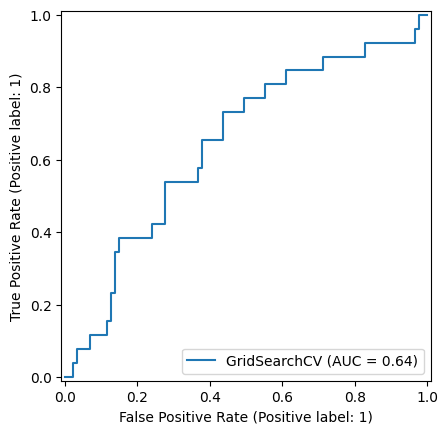

In [66]:
RocCurveDisplay.from_estimator(gs_log_reg, x_test, y_test)
plt.show()

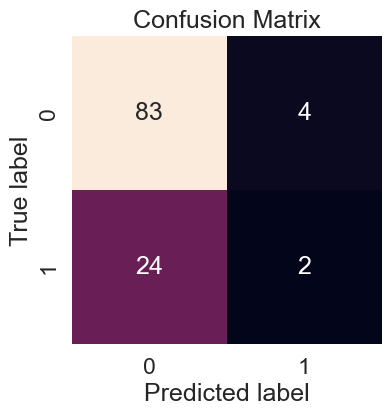

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

sns.set(font_scale=1.5)

def plot_conf_mat(y_test, y_preds):
    fig, ax = plt.subplots(figsize=(4, 4))
    
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                     annot=True,
                     fmt="d",
                     cbar=False)

    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title("Confusion Matrix")

# predictions
y_preds = gs_log_reg.predict(x_test)

plot_conf_mat(y_test, y_preds)
plt.show()

In [68]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.78      0.95      0.86        87
           1       0.33      0.08      0.12        26

    accuracy                           0.75       113
   macro avg       0.55      0.52      0.49       113
weighted avg       0.67      0.75      0.69       113



In [69]:
train_scores = []
test_scores = []

neighbors = range(1, 21)

knn = KNeighborsClassifier()

for i in neighbors:
    knn.set_params(n_neighbors=i)
    knn.fit(x_train, y_train)
    
    train_scores.append(knn.score(x_train, y_train))
    test_scores.append(knn.score(x_test, y_test))

Maximum KNN Score on the test data: 78.76%


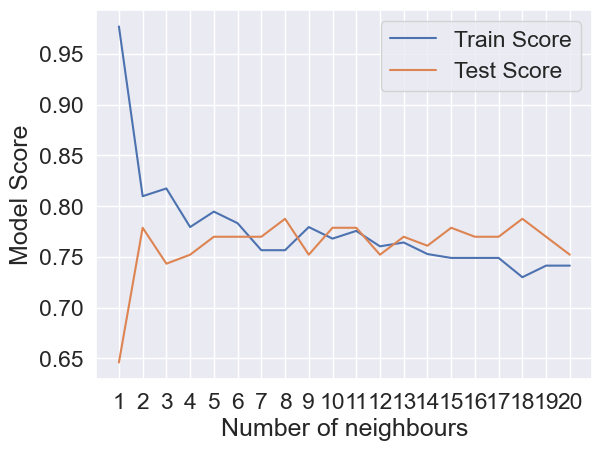

In [70]:


plt.plot(neighbors, train_scores, label="Train Score")
plt.plot(neighbors, test_scores, label="Test Score")

plt.xticks(np.arange(1, 21, 1))
plt.xlabel("Number of neighbours")
plt.ylabel("Model Score")
plt.legend()

print(f"Maximum KNN Score on the test data: {max(test_scores)*100:.2f}%")

plt.show()

In [71]:


rf_grid = {
    "n_estimators": np.arange(10, 1000, 50),
    "max_depth": [None, 3, 5, 10],
    "min_samples_split": np.arange(2, 20, 2),
    "min_samples_leaf": np.arange(1, 20, 2)
}

rs_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_grid,
    cv=5,
    n_iter=20,
    verbose=True,
    n_jobs=-1,
    random_state=42
)

rs_rf.fit(x_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 3, ...], 'min_samples_leaf': array([ 1, 3..., 15, 17, 19]), 'min_samples_split': array([ 2, 4..., 14, 16, 18]), 'n_estimators': array([ 10, ...60, 910, 960])}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-v

In [72]:
rs_rf.best_params_

{'n_estimators': np.int64(260),
 'min_samples_split': np.int64(16),
 'min_samples_leaf': np.int64(9),
 'max_depth': 10}

In [73]:
model_scores

{'Logistic Regression': 0.7522123893805309,
 'KNN': 0.7699115044247787,
 'Random Forest': 0.672566371681416}

The final model evaluation shows satisfactory scores, indicating good predictive performance for identifying repeat blood donors.

## Conclusion:
The final model evaluation shows good performance based on the obtained scores. This indicates that the model is able to predict repeat blood donors effectively using the given features. Hence, the model can be useful for identifying potential donors and supporting blood donation campaigns.